# Collider Ring Studies (twiss_ir1ccma_hybrid_v06).

In [123]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from mint import lattice_tools as lt
from mint import beam_optics as bopt
from mint import const, xsecs
from mint.MuC import MuDecaySimulator
from mint import plot_tools as pt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Create main collider-ring lattice

In [200]:
twiss_file = "beam-optics/twiss_ir1ccma_hybrid_v06.outx"

ring_df = lt.get_lattice_dataframe_from_tfs(twiss_file)
ring_dict = bopt.create_smoothed_lattice(
    ring_df,
    emittance_RMS=25e-6/(5e3/0.105), # meters.rad
    n_elements=120000,
    rotated=True,
    if_sublattice=False,
    midpoint=True
)
ring_lattice = lt.Lattice(**ring_dict)
ring_lattice.name = "twiss_ir1ccma_hybrid_v06"
ring_lattice.short_name = "ir1ccma_v06"

# Operation assumptions
ring_lattice.Nmu_per_bunch = 2e12
ring_lattice.finj = 5.0
ring_lattice.bunch_multiplicity = 1.0
ring_lattice.duty_factor = 1 / np.pi

print(f"Lattice: {ring_lattice.name}")
print(f"Ring circumference: {ring_lattice.s(1)/1e3:.2f} km")

Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x141618190>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x14161bb10>
Setting additional betx to <scipy.interpolate._interpolate.interp1d object at 0x1416187d0>
Setting additional bety to <scipy.interpolate._interpolate.interp1d object at 0x1424a42d0>
Setting additional gamx to <scipy.interpolate._interpolate.interp1d object at 0x1424a5ea0>
Setting additional gamy to <scipy.interpolate._interpolate.interp1d object at 0x1424a7660>
Setting additional alfx to <scipy.interpolate._interpolate.interp1d object at 0x1424a6ee0>
Setting additional alfy to <scipy.interpolate._interpolate.interp1d object at 0x1423b4cd0>
Setting additional cov_x_xp to <scipy.interpolate._interpolate.interp1d object at 0x1423b5fe0>
Setting additional cov_y_yp to <scipy.interpolate._interpolate.interp1d object at 0x1423b5630>
Setting additional sigma_xp to <scipy.interpolate._interpolate.

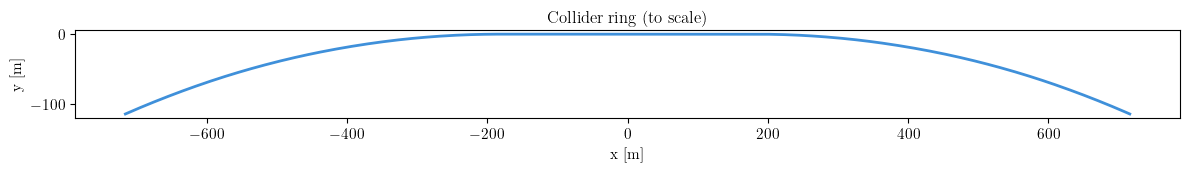

In [201]:
# Quick geometry and reference momentum profile
u = np.linspace(0, 1, 4000)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(ring_lattice.x(u)/100, ring_lattice.y(u)/100, lw=2.0)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Collider ring (to scale)")
ax.set_aspect("equal", adjustable="box")

fig.tight_layout()

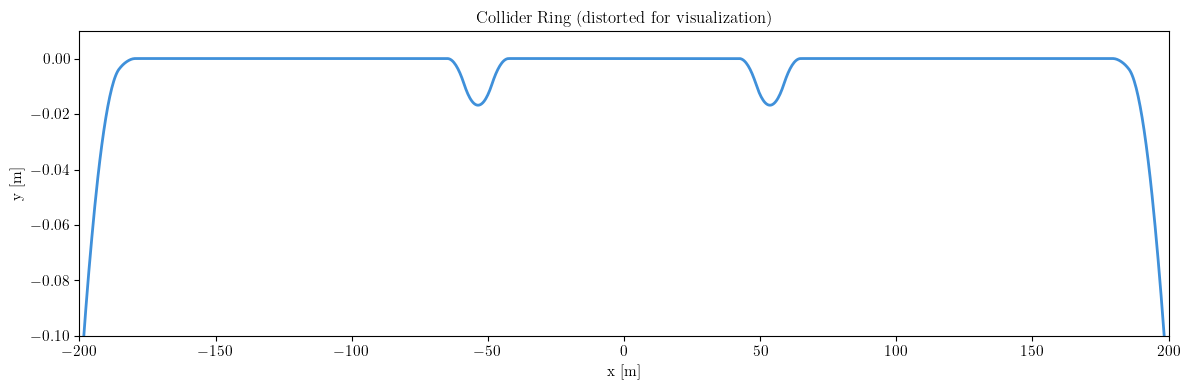

In [202]:
# Quick geometry and reference momentum profile
u = np.linspace(0, 1, 4000)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(ring_lattice.x(u)/100, ring_lattice.y(u)/100, lw=2)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Collider Ring (distorted for visualization)")
ax.set_ylim(-0.1,0.01)
ax.set_xlim(-200,200)
fig.tight_layout()

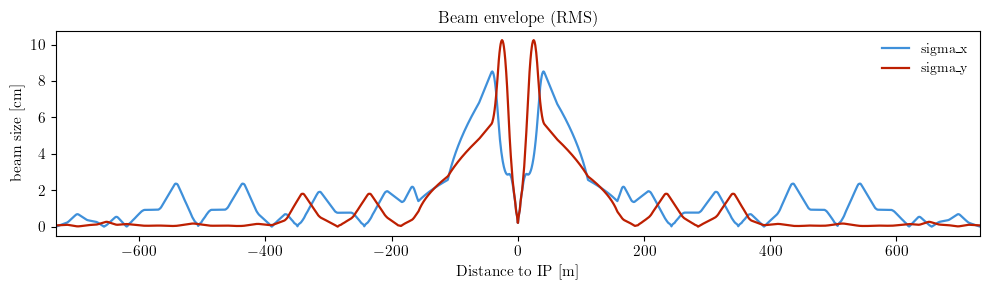

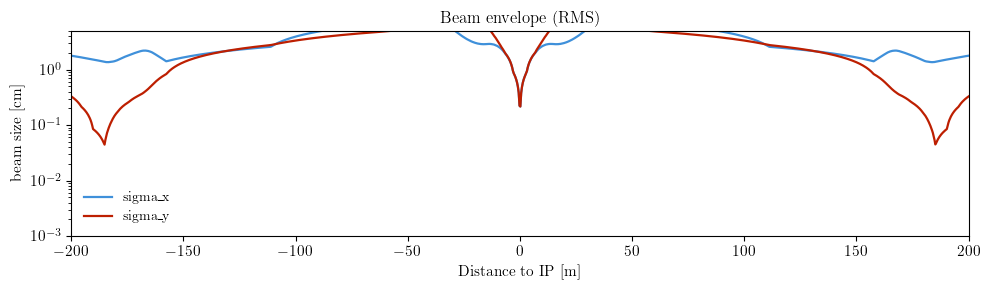

In [ ]:
# Plot beam envelope (RMS) vs longitudinal position s [m]
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x = ring_dict["beamsize_x"](u)
sigma_y = ring_dict["beamsize_y"](u)

fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(delta_s_m, sigma_x, label="sigma_x", lw=1.6)
ax_env.plot(delta_s_m, sigma_y, label="sigma_y", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam size [cm]")
ax_env.set_title("Beam envelope (RMS)")
ax_env.legend(frameon=False)
ax_env.set_xlim(delta_s_m.min(), delta_s_m.max())
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_envelope.pdf", dpi=300, bbox_inches="tight")



fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(delta_s_m, sigma_x, label="sigma_x", lw=1.6)
ax_env.plot(delta_s_m, sigma_y, label="sigma_y", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam size [cm]")
ax_env.set_ylim(1e-3, 5)
ax_env.set_yscale('log')
ax_env.set_title("Beam envelope (RMS)")
ax_env.legend(frameon=False)
ax_env.set_xlim(delta_s_m.mean() - 200, delta_s_m.mean() + 200)
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_envelope_zoomed.pdf", dpi=300, bbox_inches="tight")


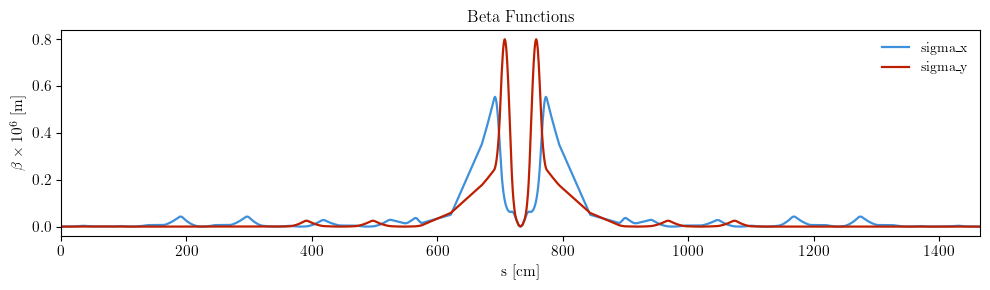

In [204]:
# Plot beam envelope (RMS) vs longitudinal position s [m]
s_m = ring_lattice.s(u) * 1e-2
sigma_x = ring_dict["betx"](u) * 1e-6
sigma_y = ring_dict["bety"](u) * 1e-6

fig_env, ax_env = plt.subplots(figsize=(10, 3))
ax_env.plot(s_m, sigma_x, label="sigma_x", lw=1.6)
ax_env.plot(s_m, sigma_y, label="sigma_y", lw=1.6)
ax_env.set_xlabel(r"s [cm]")
ax_env.set_ylabel(r"$\beta \times 10^{6}$ [m]")
ax_env.set_title("Beta Functions")
ax_env.legend(frameon=False)
ax_env.set_xlim(s_m.min(), s_m.max())
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beta_functions.pdf", dpi=300, bbox_inches="tight")


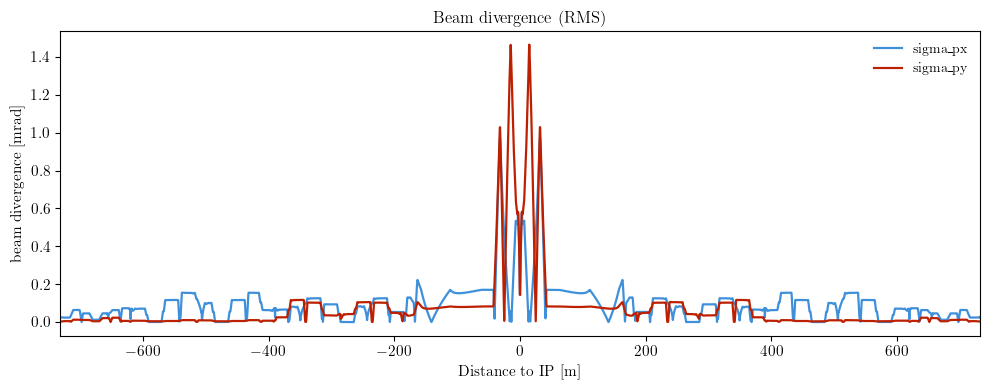

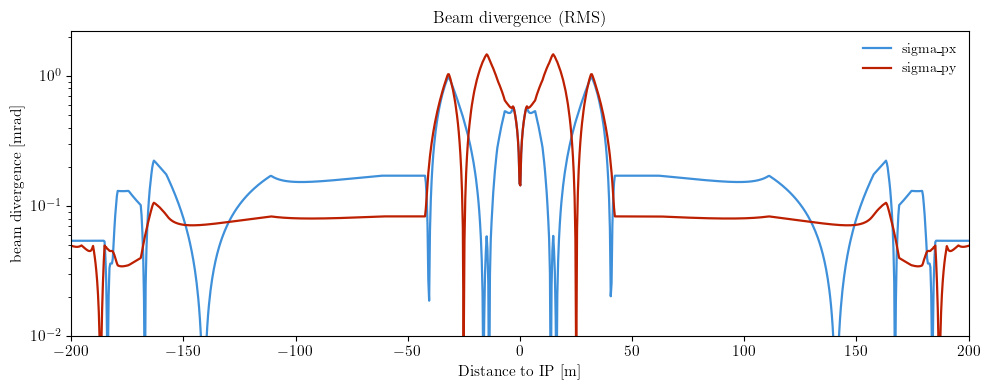

In [205]:
# Plot beam envelope (RMS) vs longitudinal position s [m]
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x_mrad = ring_dict["beamdiv_x"](u)*1e3
sigma_y_mrad = ring_dict["beamdiv_y"](u)*1e3

fig_env, ax_env = plt.subplots(figsize=(10, 4))
ax_env.plot(delta_s_m, sigma_x_mrad, label=r"sigma_{px}", lw=1.6)
ax_env.plot(delta_s_m, sigma_y_mrad, label=r"sigma_{py}", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam divergence [mrad]")
ax_env.set_title("Beam divergence (RMS)")
ax_env.legend(frameon=False)
ax_env.set_xlim(delta_s_m.min(), delta_s_m.max())
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_divergence.pdf", dpi=300, bbox_inches="tight")

# ZOOMED IN
# Plot beam envelope (RMS) vs longitudinal position s [m]
delta_s_m = (ring_lattice.s(u) - ring_lattice.s(u).mean())*1e-2
sigma_x_mrad = ring_dict["beamdiv_x"](u)*1e3
sigma_y_mrad = ring_dict["beamdiv_y"](u)*1e3

fig_env, ax_env = plt.subplots(figsize=(10, 4))
ax_env.plot(delta_s_m, sigma_x_mrad, label=r"sigma_{px}", lw=1.6)
ax_env.plot(delta_s_m, sigma_y_mrad, label=r"sigma_{py}", lw=1.6)
ax_env.set_xlabel("Distance to IP [m]")
ax_env.set_ylabel("beam divergence [mrad]")
ax_env.set_title("Beam divergence (RMS)")
ax_env.legend(frameon=False)
ax_env.set_yscale('log')
ax_env.set_ylim(0.01, None)
ax_env.set_xlim(delta_s_m.mean() - 200, delta_s_m.mean() + 200)
fig_env.tight_layout()
fig_env.savefig("plots/hybrid_v06_beam_divergence_zoomed.pdf", dpi=300, bbox_inches="tight")

## Simulate forward neutrino flux

In [206]:
n_evals = 1e6

ring_sims = {
    "numu": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numu", direction="right", n_evals=n_evals, beam_dynamics=True),
    "nue": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals, beam_dynamics=True),
    "numu_nobd": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="numu", direction="right", n_evals=n_evals, beam_dynamics=False),
    "nue_nobd": MuDecaySimulator(cycles=1e3, muon_polarization=0.0, nuflavor="nue", direction="right", n_evals=n_evals, beam_dynamics=False),
}

for flavor, sim in ring_sims.items():
    sim.decay_muons()
    sim.place_muons_on_lattice(lattice=ring_lattice, direction="clockwise")

sample_size: 937568
pos x range: -11388.358466856322 -2888.3404425956655 3.5552689506842756e-05
pos y range: -8.533161380176727 -5.0609266023021424e-05 6.965731903786074
pos z range: -71649.54907701342 -65.21641264476273 71648.35014031481
s_in_turn min/max: 0.011822759610367939 146489.3870974821
u_parameter min/max: 8.070722107937273e-08 0.9999993013382736
mutimes min/max: 1.004967735969861e-08 0.004886358917553609
muon_lifetime min/max: 0.10396625395778492 0.10396625395778492
sample_size: 937578
pos x range: -11388.3426393833 -2882.003246074171 3.143280155789655e-05
pos y range: -8.304740933832436 6.319430870676103e-05 9.08306552814469
pos z range: -71649.51283920689 -38.27171933605802 71648.42590018327
s_in_turn min/max: 0.04786542753572576 146489.47168353712
u_parameter min/max: 3.267499102998585e-07 0.9999998787589154
mutimes min/max: 2.1397093208042674e-09 0.004886348979294348
muon_lifetime min/max: 0.10396625395778492 0.10396625395778492
sample_size: 937365
pos x range: -11388.23

In [240]:
# Detector and running assumptions for event-rate estimate
det_radius = 0.1e2  # cm (2 m radius)
detector_length_cm = 10e2  # 10 m target depth
rho_g_cm3 = 1.00
nucleon_column_density = rho_g_cm3 * detector_length_cm / const.m_proton_in_g
detector_area_cm2 = np.pi * det_radius**2

det_location = np.array([0.0, 0.0, 1e5])  # 1 km downstream

bunches_per_year = (
    ring_lattice.finj
    * ring_lattice.bunch_multiplicity
    * ring_lattice.duty_factor
    * const.s_in_year
)


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_1314/1613395900.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


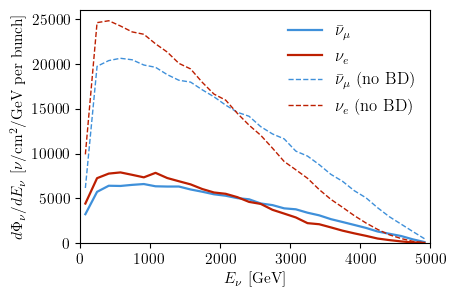

In [241]:
# Forward detector setup (on-axis, downstream)
energy_edges = np.linspace(0, 5e3, 31)
energy_centers = 0.5 * (energy_edges[1:] + energy_edges[:-1])

flux_results = {}
for flavor, sim in ring_sims.items():
    e_edges, flux = sim.get_flux_at_generic_location(
        det_location=det_location,
        det_radius=det_radius,
        ebins=energy_edges,
        per_cm2=True,
        normalization=1,
    )

    if np.isscalar(e_edges):
        flux = np.zeros_like(energy_centers)
    flux_results[flavor] = flux

fig, ax = pt.std_fig()
label = {"numu": r"$\bar\nu_\mu$", "nue": r"$\nu_e$"}
for i, flavor in enumerate(["numu", "nue"]):
    ax.plot(energy_centers, flux_results[flavor], lw=1.6, label=label[flavor])
    # ax[i].set_yscale("log")
    ax.set_xlabel(r"$E_\nu$ [GeV]")

plt.gca().set_prop_cycle(None)
for i, flavor in enumerate(["numu", "nue"]):
    ax.plot(energy_centers, flux_results[flavor+'_nobd'], lw=1, ls='--', label=label[flavor]+r' (no BD)')
    # ax[i].set_yscale("log")
    ax.set_xlabel(r"$E_\nu$ [GeV]")

ax.set_xlim(0, 5e3)
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=12)
ax.set_ylabel(r"$d\Phi_\nu/dE_\nu$ [$\nu$/cm$^{2}$/GeV per bunch]")
fig.tight_layout()
fig.savefig("plots/hybrid_v06_flux_spectrum.pdf", dpi=300, bbox_inches="tight")

In [242]:
def get_flux_at_annuli(sim,  flavor, r_edges=np.linspace(0.0, det_radius, 51)):
    # compute and plot radial event-rate density dN/dr at 1 km (det_location already in cm)
    r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])
    dr = np.diff(r_edges)  # cm

    cum_events_per_bunch = {fl: [] for fl in ring_sims}

    for r in r_edges:
        _, flux = sim.get_flux_at_generic_location(
            det_location=det_location,        # center on axis
            det_radius=r,                     # disk radius in cm
            ebins=energy_edges,
            per_cm2=True,
            normalization=1,
        )
        if np.isscalar(_) or flux is None:
            flux = np.zeros_like(energy_centers)
        sigma = xsecs.total_xsecs[flavor](energy_centers)
        p_int = sigma * nucleon_column_density
        area_disk = np.pi * r**2  # cm^2
        events_per_bunch_disk = np.trapz(flux * p_int, energy_centers) * area_disk
        cum_events_per_bunch[flavor].append(events_per_bunch_disk)

    # convert cumulative lists -> arrays
    for fl in cum_events_per_bunch:
        cum_events_per_bunch[fl] = np.array(cum_events_per_bunch[fl])

    # annulus events per bunch and per year, convert to per meter (multiply by 100)
    dN_dr_per_year_per_m = {}
    annulus_events_per_bunch = np.diff(cum_events_per_bunch[flavor])         # events per bunch in annulus (per cm width = dr)
    dN_dr_per_year_per_cm = annulus_events_per_bunch / dr               # events per bunch per cm
    dN_dr_per_year_per_cm *= bunches_per_year                             # events per year per cm
    dN_dr_per_year_per_m = dN_dr_per_year_per_cm * 100.0            # events per year per m
    return dN_dr_per_year_per_m

In [218]:
r_edges = np.linspace(0.0, 10e2, 201)  # cm
dN_dr_per_year_per_m_numu = get_flux_at_annuli(ring_sims["numu"], "numu", r_edges=r_edges)
dN_dr_per_year_per_m_nue = get_flux_at_annuli(ring_sims["nue"], "nue", r_edges=r_edges)
dN_dr_per_year_per_m_numu_noBD = get_flux_at_annuli(ring_sims["numu_nobd"], "numu", r_edges=r_edges)
dN_dr_per_year_per_m_nue_noBD = get_flux_at_annuli(ring_sims["nue_nobd"], "nue", r_edges=r_edges)

No flux through detector.


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_1314/867044335.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  events_per_bunch_disk = np.trapz(flux * p_int, energy_centers) * area_disk


No flux through detector.
No flux through detector.
No flux through detector.


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_1314/2148571720.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


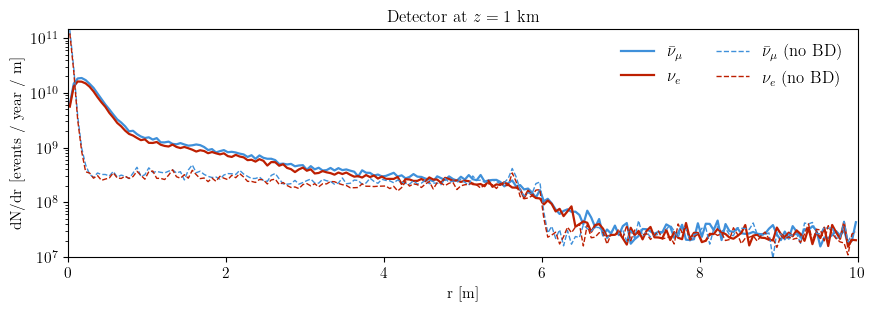

In [233]:
# plot
fig, ax = pt.std_fig(figsize=(10, 3))

r_centers = 0.5 * (r_edges[1:] + r_edges[:-1])
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numu, lw=1.6, label=label["numu"])
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_nue, lw=1.6, label=label["nue"])

plt.gca().set_prop_cycle(None)

ax.plot(r_centers/100.0, dN_dr_per_year_per_m_numu_noBD, lw=1., ls='--', label=label["numu"]+r' (no BD)')
ax.plot(r_centers/100.0, dN_dr_per_year_per_m_nue_noBD, lw=1., ls='--', label=label["nue"]+r' (no BD)')

ax.set_xlabel("r [m]")
ax.set_ylabel("dN/dr [events / year / m]")
ax.set_xlim(0, 10)
# ax.set_xscale
ax.set_ylim(1e7, None)
ax.set_yscale('log')
ax.legend(frameon=False, fontsize=12, ncol=2)
ax.set_title(r"Detector at $z = 1$ km")
fig.tight_layout()
fig.savefig("plots/hybrid_v06_event_rate_radial.pdf", dpi=300, bbox_inches="tight")

## Estimate forward event rate

Estimated total forward event rate (numu): 2.929e+09 events/year
Estimated total forward event rate (nue):  2.571e+09 events/year


/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_1314/511113567.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_1314/511113567.py:49: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  tot_numu = np.trapz(event_results["numu"]["dN_dE_per_year"], energy_centers)
/var/folders/dl/ccbsfs591r1fhgcws28m8xy40000gn/T/ipykernel_1314/511113567.py:50: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  tot_nue = np.trapz(event_results["nue"]["dN_dE_per_year"], energy_centers)


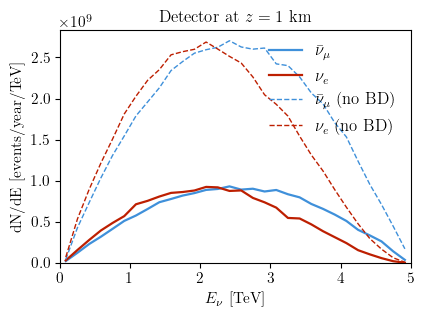

In [244]:
GeV_to_TeV = 1e-3
event_results = {}
for flavor in ["numu", "nue"]:
    sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
    p_int = sigma_tot * nucleon_column_density

    # Here we multiply back by the det area.
    dN_dE_per_decay = flux_results[flavor] * detector_area_cm2 * p_int

    # dN/dE per year
    dN_dE_per_year = dN_dE_per_decay * bunches_per_year

    event_results[flavor] = {
        "dN_dE_per_decay": dN_dE_per_decay,
        "dN_dE_per_year": dN_dE_per_year,
    }


for flavor in ["numu", "nue"]:
    sigma_tot = xsecs.total_xsecs[flavor](energy_centers)
    p_int = sigma_tot * nucleon_column_density

    # Here we multiply back by the det area.
    dN_dE_per_decay = flux_results[flavor+'_nobd'] * detector_area_cm2 * p_int

    # dN/dE per year
    dN_dE_per_year = dN_dE_per_decay * bunches_per_year

    event_results[flavor+'_nobd'] = {
        "dN_dE_per_decay": dN_dE_per_decay,
        "dN_dE_per_year": dN_dE_per_year,
    }

fig, ax = pt.std_fig()
for flavor in ["numu", "nue"]:
    ax.plot(energy_centers*GeV_to_TeV, event_results[flavor]["dN_dE_per_year"]/GeV_to_TeV, lw=1.6, label=label[flavor])
plt.gca().set_prop_cycle(None)
for flavor in ["numu", "nue"]:
    ax.plot(energy_centers*GeV_to_TeV, event_results[flavor+"_nobd"]["dN_dE_per_year"]/GeV_to_TeV, lw=1., ls='--', label=label[flavor]+r' (no BD)')
    # ax.set_yscale("log")
ax.set_xlabel(r"$E_\nu$ [TeV]")
ax.set_ylabel(r"dN/dE [events/year/TeV]")
ax.set_xlim(0, 5)
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=12)
ax.set_title(r"Detector at $z = 1$ km")
fig.tight_layout()

tot_numu = np.trapz(event_results["numu"]["dN_dE_per_year"], energy_centers)
tot_nue = np.trapz(event_results["nue"]["dN_dE_per_year"], energy_centers)

print(f"Estimated total forward event rate (numu): {tot_numu:.3e} events/year")
print(f"Estimated total forward event rate (nue):  {tot_nue:.3e} events/year")

fig.savefig("plots/hybrid_v06_event_rate_spectrum.pdf", dpi=300, bbox_inches="tight")